In [1]:
!pip install adjustText

In [12]:
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

In [13]:
# ------------------------------------------------------------------------------
# [환경 설정] 한글 깨짐 방지 및 출력 경로 설정
# ------------------------------------------------------------------------------
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

out_dir = "./" 
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 데이터 로드 (상대 경로 및 기존 절대 경로 다중 대응)
file_path_relative = '동복천2 정밀조사 관련 kendall plot.csv'
file_path_absolute = 'C:/Users/User/Desktop/동복천2 정밀조사 관련 kendall plot.csv'

try:
    df = pd.read_csv(file_path_relative, encoding='utf-8-sig')
except Exception:
    try:
        df = pd.read_csv(file_path_relative, encoding='cp949')
    except Exception:
        try:
            df = pd.read_csv(file_path_absolute, encoding='utf-8-sig')
        except Exception:
            df = pd.read_csv(file_path_absolute, encoding='euc-kr')

# 동위원소 측정값 결측치 제거
plot_df = df.dropna(subset=['d15N', 'd18O']).copy()

# 데이터 컬럼 존재 여부 동적 체크
has_month = 'month' in plot_df.columns
has_point = 'point' in plot_df.columns
has_spot = 'spot' in plot_df.columns

# 월별 색상 맵 자동 생성 (month 컬럼 존재 시)
if has_month:
    unique_months = sorted(plot_df['month'].unique())
    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    color_map = {m: palette[i % len(palette)] for i, m in enumerate(unique_months)}

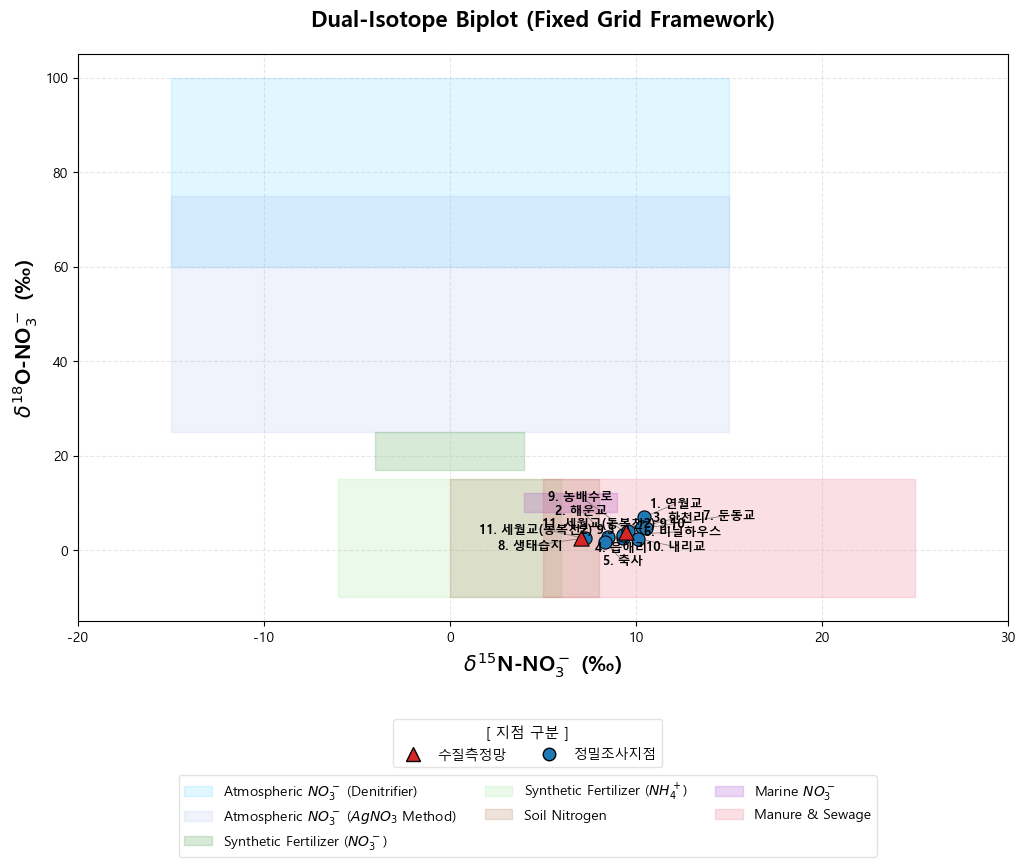

In [14]:
# ==============================================================================
# Dual-Isotope biplot (버전 1: 고정 축 범위)
# ==============================================================================
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(12, 9))

    # 사각형 오염원 영역 패치 수집
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    texts = []

    # 데이터 scatter 플로팅
    if has_month:
        for month, group in plot_df.groupby('month'):
            for _, row in group.iterrows():
                marker = '^' if (has_point and row['point'] == 'O') else 'o'
                size = 120 if (has_point and row['point'] == 'O') else 90
                ax.scatter(row['d15N'], row['d18O'], color=color_map[month],
                           marker=marker, s=size, edgecolors='k', linewidths=0.8, zorder=5)
                if has_spot:
                    t = ax.text(row['d15N'], row['d18O'], str(row['spot']),
                                fontsize=9, fontweight='semibold', zorder=6, ha='center', va='center')
                    texts.append(t)
    elif has_point:
        for _, row in plot_df.iterrows():
            is_monitoring = (row['point'] == 'O')
            color = '#d62728' if is_monitoring else '#1f77b4'
            marker = '^' if is_monitoring else 'o'
            size = 120 if is_monitoring else 90
            ax.scatter(row['d15N'], row['d18O'], color=color,
                       marker=marker, s=size, edgecolors='k', linewidths=0.8, zorder=5)
            if has_spot:
                t = ax.text(row['d15N'], row['d18O'], str(row['spot']),
                            fontsize=9, fontweight='semibold', zorder=6, ha='center', va='center')
                texts.append(t)
    else:
        ax.scatter(plot_df['d15N'], plot_df['d18O'], color='#1f77b4',
                   marker='o', s=100, edgecolors='k', linewidths=0.8, zorder=5)
        if has_spot:
            for _, row in plot_df.iterrows():
                t = ax.text(row['d15N'], row['d18O'], str(row['spot']),
                            fontsize=9, fontweight='semibold', zorder=6, ha='center', va='center')
                texts.append(t)

    # 겹침 방지 adjust_text 적용
    if HAS_ADJUST_TEXT and texts:
        adjust_text(texts, 
                    expand_points=(1.5, 1.5), 
                    expand_text=(1.2, 1.2),
                    arrowprops=dict(arrowstyle="-", color='dimgray', lw=0.6, alpha=0.8))

    # 축 라벨 및 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Fixed Grid Framework)", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(-20, 30)
    ax.set_ylim(-15, 105)

    # 1. 우측 범례: [ 월별 색상 ] (month 존재 시)
    if has_month:
        data_legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markersize=10, label=f'   {m}')
            for m in unique_months
        ]
        ax.legend(handles=data_legend_elements, title='[ 월별 색상 ]', loc='upper left', bbox_to_anchor=(1.02, 1.0), 
                  fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.4)

    # 2. 하단 범례 (1단): [ 지점 구분 ] (point 존재 시)
    if has_point:
        point_handles = [
            Line2D([0], [0], marker='^', color='w', markerfacecolor='#d62728', markeredgecolor='k', markersize=10, label='수질측정망'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markeredgecolor='k', markersize=9, label='정밀조사지점')
        ]
        fig.legend(handles=point_handles, title='[ 지점 구분 ]', loc='lower center', bbox_to_anchor=(0.5, 0.08),
                   ncol=2, fontsize=10, title_fontsize=10.5, frameon=True, facecolor='white', edgecolor='gainsboro')

    # 3. 하단 범례 (2단): [ 오염원 영역 ]
    fig.legend(handles=rect_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=10,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    # 하단 여백 확보
    plt.subplots_adjust(bottom=0.25) 

    # 이미지 저장 및 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_fixed_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[경고] 데이터가 존재하지 않습니다.")

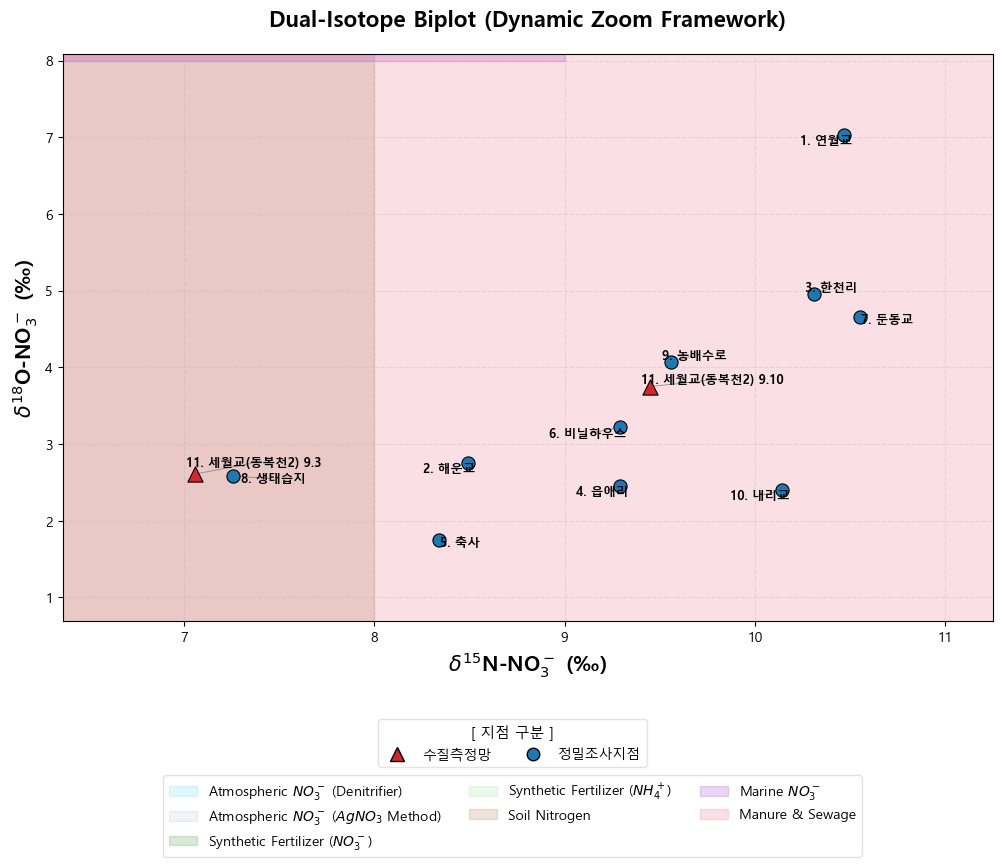

In [15]:
# ==============================================================================
# Dual-Isotope biplot (버전 2: 여백 기반 동적 축 범위 변형)
# ==============================================================================
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(12, 9))

    # 사각형 오염원 영역 패치 수집
    rect_handles = []
    r1 = Rectangle((-15, 60), 30, 40, fill=True, alpha=0.12, color='deepskyblue', label='Atmospheric $NO_3^-$ (Denitrifier)')
    r2 = Rectangle((-15, 25), 30, 50, fill=True, alpha=0.08, color='royalblue', label='Atmospheric $NO_3^-$ ($AgNO_3$ Method)')
    r3 = Rectangle((-4, 17), 8, 8, fill=True, alpha=0.18, color='forestgreen', label='Synthetic Fertilizer ($NO_3^-$)')
    r4 = Rectangle((-6, -10), 12, 25, fill=True, alpha=0.10, color='limegreen', label='Synthetic Fertilizer ($NH_4^+$)')
    r5 = Rectangle((0, -10), 8, 25, fill=True, alpha=0.15, color='saddlebrown', label='Soil Nitrogen')
    r6 = Rectangle((4, 8), 5, 4, fill=True, alpha=0.20, color='darkorchid', label='Marine $NO_3^-$')
    r7 = Rectangle((5, -10), 20, 25, fill=True, alpha=0.13, color='crimson', label='Manure & Sewage')
    
    for r in [r1, r2, r3, r4, r5, r6, r7]:
        ax.add_patch(r)
        rect_handles.append(r)

    texts = []

    # 데이터 scatter 플로팅
    if has_month:
        for month, group in plot_df.groupby('month'):
            for _, row in group.iterrows():
                marker = '^' if (has_point and row['point'] == 'O') else 'o'
                size = 120 if (has_point and row['point'] == 'O') else 90
                ax.scatter(row['d15N'], row['d18O'], color=color_map[month],
                           marker=marker, s=size, edgecolors='k', linewidths=0.8, zorder=5)
                if has_spot:
                    t = ax.text(row['d15N'], row['d18O'], str(row['spot']),
                                fontsize=9, fontweight='semibold', zorder=6, ha='center', va='center')
                    texts.append(t)
    elif has_point:
        for _, row in plot_df.iterrows():
            is_monitoring = (row['point'] == 'O')
            color = '#d62728' if is_monitoring else '#1f77b4'
            marker = '^' if is_monitoring else 'o'
            size = 120 if is_monitoring else 90
            ax.scatter(row['d15N'], row['d18O'], color=color,
                       marker=marker, s=size, edgecolors='k', linewidths=0.8, zorder=5)
            if has_spot:
                t = ax.text(row['d15N'], row['d18O'], str(row['spot']),
                            fontsize=9, fontweight='semibold', zorder=6, ha='center', va='center')
                texts.append(t)
    else:
        ax.scatter(plot_df['d15N'], plot_df['d18O'], color='#1f77b4',
                   marker='o', s=100, edgecolors='k', linewidths=0.8, zorder=5)
        if has_spot:
            for _, row in plot_df.iterrows():
                t = ax.text(row['d15N'], row['d18O'], str(row['spot']),
                            fontsize=9, fontweight='semibold', zorder=6, ha='center', va='center')
                texts.append(t)

    # 동적 스케일링 및 축 범위 확정
    x_min, x_max = plot_df['d15N'].min(), plot_df['d15N'].max()
    y_min, y_max = plot_df['d18O'].min(), plot_df['d18O'].max()
    
    x_padding = (x_max - x_min) * 0.20 if x_max != x_min else 2.0
    y_padding = (y_max - y_min) * 0.20 if y_max != y_min else 2.0
    
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # 축 라벨 및 디자인 설정
    ax.set_xlabel(r'$\delta^{15}$N-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.set_ylabel(r'$\delta^{18}$O-NO$_3^-$ (‰)', fontsize=15, fontweight='semibold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_title("Dual-Isotope Biplot (Dynamic Zoom Framework)", fontsize=16, fontweight='bold', pad=20)

    # 라벨 위치 조정
    if HAS_ADJUST_TEXT and texts:
        adjust_text(texts, 
                    expand_points=(1.1, 1.2), 
                    expand_text=(1.1, 1.2),
                    force_points=0.1,
                    force_text=0.2,
                    arrowprops=dict(arrowstyle="-", color='dimgray', lw=0.6, alpha=0.7))

    # 1. 우측 범례: [ 월별 색상 ]
    if has_month:
        data_legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markersize=10, label=f'   {m}')
            for m in unique_months
        ]
        ax.legend(handles=data_legend_elements, title='[ 월별 색상 ]', loc='upper left', bbox_to_anchor=(1.02, 1.0), 
                  fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro', labelspacing=0.4)

    # 2. 하단 범례 (1단): [ 지점 구분 ]
    if has_point:
        point_handles = [
            Line2D([0], [0], marker='^', color='w', markerfacecolor='#d62728', markeredgecolor='k', markersize=10, label='수질측정망'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markeredgecolor='k', markersize=9, label='정밀조사지점')
        ]
        fig.legend(handles=point_handles, title='[ 지점 구분 ]', loc='lower center', bbox_to_anchor=(0.5, 0.08),
                   ncol=2, fontsize=10, title_fontsize=10.5, frameon=True, facecolor='white', edgecolor='gainsboro')

    # 3. 하단 범례 (2단): [ 오염원 영역 ]
    fig.legend(handles=rect_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=10,
               frameon=True, facecolor='white', edgecolor='gainsboro')
    
    # 하단 여백 확보
    plt.subplots_adjust(bottom=0.25) 

    # 이미지 저장 및 출력
    fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_dynamic_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[경고] 데이터가 존재하지 않습니다.")